
Loading datasets...

[OK] Loaded: ../data/Combined data.csv | Shape: (53043, 3)
[OK] Loaded: ../data/Mental_Health_FAQ.csv | Shape: (98, 3)
[OK] Loaded: ../data/Suicide_Detection.csv | Shape: (232074, 3)

Final merged dataset shape: (282682, 2)

Sample rows:
                                                text    label
0                                         oh my gosh  anxiety
1  trouble sleeping confused mind restless heart ...  anxiety
2  all wrong back off dear forward doubt stay in ...  anxiety
3  i ve shifted my focus to something else but i ...  anxiety
4  i m restless and restless it s been a month no...  anxiety

Label counts before filtering:
label
suicidal                126629
non-suicide             115655
normal                   15919
depression               15086
anxiety                   3612
bipolar                   2501
stress                    2291
personality disorder       892
faq                         97
Name: count, dtype: int64

Label counts after remov

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 120, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 120, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 120, 256)            │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 9)                   │             585 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,012,873 (11.49 MB)

 Trainable params: 3,012,873 (11.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
6007/6007 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.3469 - loss: 1.9811
Epoch 1: val_accuracy improved from None to 0.55233, saving model to best_mental_health_bilstm_model.keras
6007/6007 ━━━━━━━━━━━━━━━━━━━━ 2728s 450ms/step - accuracy: 0.4228 - loss: 1.8389 - val_accuracy: 0.5523 - val_loss: 1.4686 - learning_rate: 0.0010
Epoch 2/20
6007/6007 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.5765 - loss: 1.4494
Epoch 2: val_accuracy improved from 0.55233 to 0.68896, saving model to best_mental_health_bilstm_model.keras
6007/6007 ━━━━━━━━━━━━━━━━━━━━ 2596s 432ms/step - accuracy: 0.5889 - loss: 1.3423 - val_accuracy: 0.6890 - val_loss: 0.9817 - learning_rate: 0.0010
Epoch 3/20
6007/6007 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.6023 - loss: 1.1110
Epoch 3: val_accuracy improved from 0.68896 to 0.71470, saving model to best_mental_health_bilstm_model.keras
6007/6007 ━━━━━━━━━━━━━━━━━━━━ 2154s 359ms/step - accuracy: 0.6140 - loss: 1.0884 - val_accuracy: 0.7147 - 

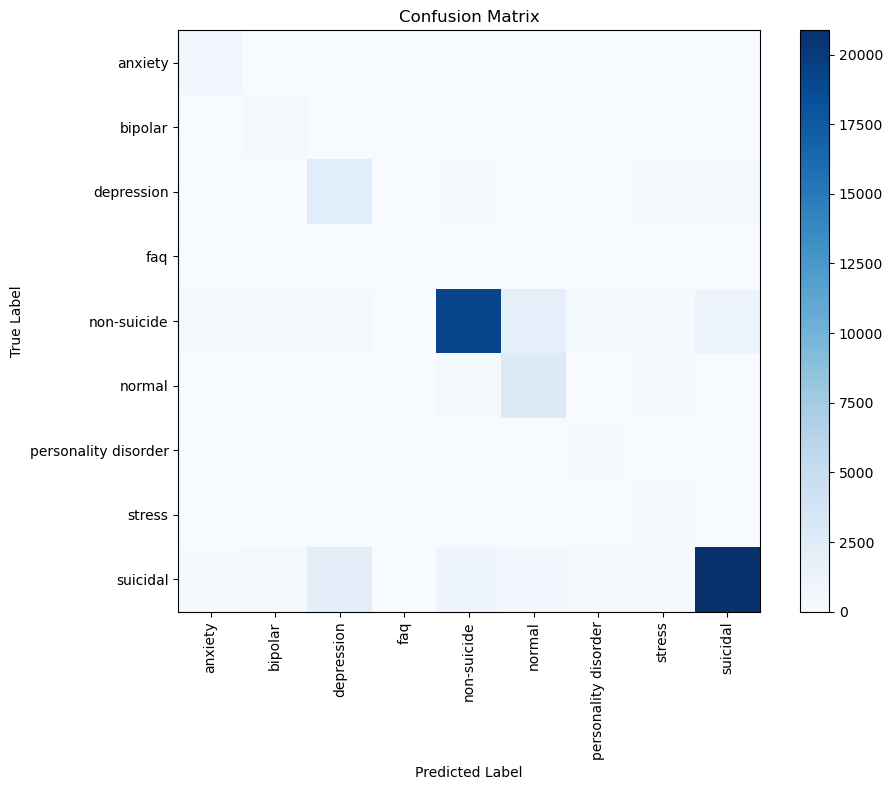

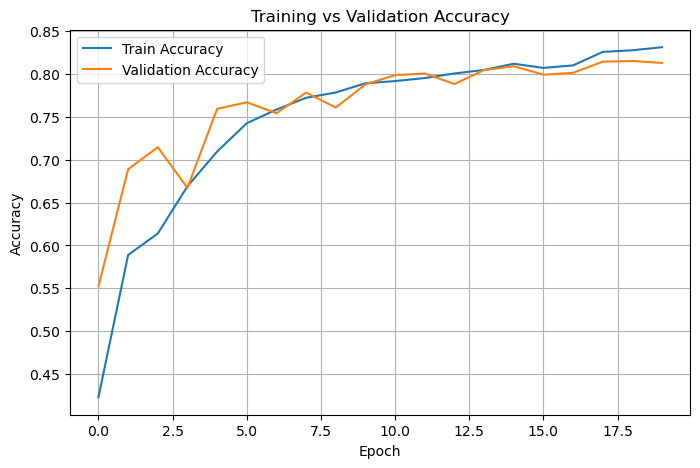

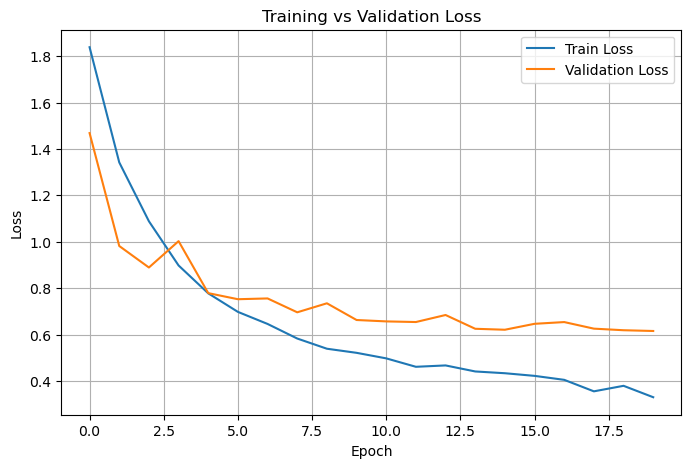


Model saved to: mental_health_bilstm_model.keras
Best model saved to: best_mental_health_bilstm_model.keras
Tokenizer saved to: mental_health_tokenizer.pkl
Label encoder saved to: mental_health_label_encoder.pkl

[INFO] Gemini API key not set. General queries will use local fallback response.

================ SAMPLE PREDICTIONS ================

User Input: I feel empty and hopeless and nothing makes me happy anymore.
Chat Response: I'm really sorry that you're feeling this way. It sounds like things may have been quite heavy for you lately. When sadness or emptiness keeps building up, even small tasks can feel difficult. Please remember that what you're feeling matters, and you do not have to handle it all alone. Reaching out to someone you trust or a mental health professional could really help.
Detected Disorder: depression
Confidence Percentage: 77.95
Top 3 Predictions: [{'label': 'depression', 'percentage': 77.95}, {'label': 'suicidal', 'percentage': 18.81}, {'label': 'non-suici

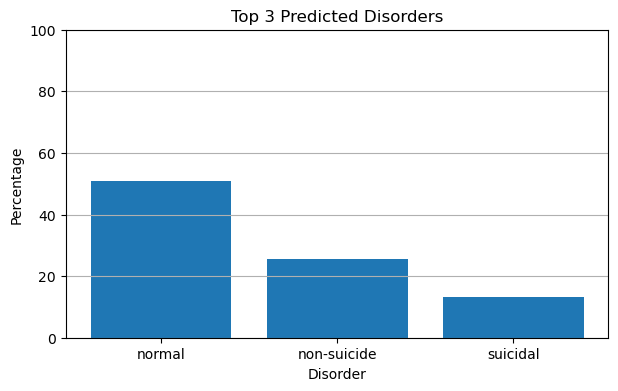

'\nfrom tensorflow.keras.models import load_model\nimport pickle\n\nloaded_model = load_model("mental_health_bilstm_model.keras")\n\nwith open("mental_health_tokenizer.pkl", "rb") as f:\n    loaded_tokenizer = pickle.load(f)\n\nwith open("mental_health_label_encoder.pkl", "rb") as f:\n    loaded_label_encoder = pickle.load(f)\n\nresult = chatbot_response(\n    "I feel anxious and scared most of the time.",\n    loaded_model,\n    loaded_tokenizer,\n    loaded_label_encoder\n)\n\nprint(result)\n'

In [1]:
# ============================================================
# MENTAL HEALTH CHATBOT TRAINING CODE
# Stronger BiLSTM + Top-3 Prediction + Sympathetic Reply + Gemini Fallback
# ============================================================

import os
import re
import json
import pickle
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout,
    SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# -----------------------------
# 0. CONFIG
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Change these paths if needed
COMBINED_PATH = "../data/Combined data.csv"
FAQ_PATH = "../data/Mental_Health_FAQ.csv"
SUICIDE_PATH = "../data/Suicide_Detection.csv"

MODEL_SAVE_PATH = "mental_health_bilstm_model.keras"
BEST_MODEL_SAVE_PATH = "best_mental_health_bilstm_model.keras"
TOKENIZER_SAVE_PATH = "mental_health_tokenizer.pkl"
LABEL_ENCODER_SAVE_PATH = "mental_health_label_encoder.pkl"

MAX_WORDS = 20000
MAX_LEN = 120
EMBED_DIM = 128
BATCH_SIZE = 32
EPOCHS = 20
MIN_SAMPLES_PER_CLASS = 20

# -----------------------------
# 1. SAFE CSV READER
# -----------------------------
def safe_read_csv(path):
    if not os.path.exists(path):
        print(f"[WARNING] File not found: {path}")
        return None
    try:
        df = pd.read_csv(path)
        print(f"[OK] Loaded: {path} | Shape: {df.shape}")
        return df
    except Exception as e:
        print(f"[ERROR] Could not read {path}: {e}")
        return None

# -----------------------------
# 2. TEXT CLEANING
# -----------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # reduce repeated chars
    text = re.sub(r"\s+", " ", text).strip()
    return text

# -----------------------------
# 3. COLUMN DETECTION
# -----------------------------
def find_text_column(df):
    possible = [
        "text", "statement", "sentence", "utterance", "message",
        "question", "questions", "content", "input", "review"
    ]
    lower_map = {c.lower(): c for c in df.columns}
    for name in possible:
        if name in lower_map:
            return lower_map[name]

    candidates = []
    for col in df.columns:
        if df[col].dtype == "object":
            avg_len = df[col].astype(str).str.len().mean()
            candidates.append((col, avg_len))
    if candidates:
        candidates.sort(key=lambda x: x[1], reverse=True)
        return candidates[0][0]
    return None

def find_label_column(df):
    possible = [
        "label", "labels", "class", "category", "target",
        "status", "emotion", "intent", "disorder"
    ]
    lower_map = {c.lower(): c for c in df.columns}
    for name in possible:
        if name in lower_map:
            return lower_map[name]
    return None

# -----------------------------
# 4. STANDARDIZATION
# -----------------------------
def standardize_df(df, text_col=None, label_col=None, default_label=None):
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=["text", "label"])

    if text_col is None:
        text_col = find_text_column(df)
    if label_col is None:
        label_col = find_label_column(df)

    if text_col is None:
        print("[WARNING] No text column found. Skipping one dataset.")
        return pd.DataFrame(columns=["text", "label"])

    out = pd.DataFrame()
    out["text"] = df[text_col].astype(str)

    if label_col is not None:
        out["label"] = df[label_col].astype(str)
    else:
        out["label"] = default_label if default_label is not None else "general"

    out["text"] = out["text"].apply(clean_text)
    out["label"] = out["label"].astype(str).str.lower().str.strip()

    # normalize some possible labels
    out["label"] = out["label"].replace({
        "suicide": "suicidal",
        "suicidal ideation": "suicidal",
        "depressed": "depression",
        "anxious": "anxiety"
    })

    out = out.dropna().drop_duplicates()
    out = out[out["text"].str.len() > 3]
    out = out[out["label"].str.len() > 0]
    out = out.reset_index(drop=True)

    return out[["text", "label"]]

# -----------------------------
# 5. LOAD DATASETS
# -----------------------------
print("\nLoading datasets...\n")

df1_raw = safe_read_csv(COMBINED_PATH)
df2_raw = safe_read_csv(FAQ_PATH)
df3_raw = safe_read_csv(SUICIDE_PATH)

# Dataset 1: Combined mental health dataset
df1 = standardize_df(df1_raw)

# Dataset 2: FAQ dataset
if df2_raw is not None:
    lower_cols = [c.lower() for c in df2_raw.columns]
    if "questions" in lower_cols:
        real_col = df2_raw.columns[lower_cols.index("questions")]
        if find_label_column(df2_raw) is None:
            df2 = standardize_df(df2_raw, text_col=real_col, default_label="faq")
        else:
            df2 = standardize_df(df2_raw, text_col=real_col)
    else:
        if find_label_column(df2_raw) is None:
            df2 = standardize_df(df2_raw, default_label="faq")
        else:
            df2 = standardize_df(df2_raw)
else:
    df2 = pd.DataFrame(columns=["text", "label"])

# Dataset 3: Suicide dataset
if df3_raw is not None:
    lower_cols = [c.lower() for c in df3_raw.columns]
    if "class" in lower_cols:
        real_label_col = df3_raw.columns[lower_cols.index("class")]
        df3 = standardize_df(df3_raw, label_col=real_label_col)
    else:
        df3 = standardize_df(df3_raw)
else:
    df3 = pd.DataFrame(columns=["text", "label"])

# Merge
df = pd.concat([df1, df2, df3], ignore_index=True)
df = df.dropna().drop_duplicates().reset_index(drop=True)

print("\nFinal merged dataset shape:", df.shape)
print("\nSample rows:")
print(df.head())

print("\nLabel counts before filtering:")
print(df["label"].value_counts())

# Remove very rare classes
label_counts = df["label"].value_counts()
valid_labels = label_counts[label_counts >= MIN_SAMPLES_PER_CLASS].index
df = df[df["label"].isin(valid_labels)].reset_index(drop=True)

print(f"\nLabel counts after removing rare classes (<{MIN_SAMPLES_PER_CLASS}):")
print(df["label"].value_counts())

if len(df) < 50:
    raise ValueError("Dataset became too small after cleaning. Please check your CSV files.")

# -----------------------------
# 6. LABEL ENCODING
# -----------------------------
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

num_classes = len(label_encoder.classes_)
print("\nClasses:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i}: {cls}")

with open(LABEL_ENCODER_SAVE_PATH, "wb") as f:
    pickle.dump(label_encoder, f)

# -----------------------------
# 7. TRAIN / TEST SPLIT
# -----------------------------
X = df["text"].values
y = df["label_id"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("\nTrain size:", len(X_train))
print("Test size :", len(X_test))

# -----------------------------
# 8. TOKENIZATION
# -----------------------------
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

with open(TOKENIZER_SAVE_PATH, "wb") as f:
    pickle.dump(tokenizer, f)

print("\nPadded shapes:")
print("X_train_pad:", X_train_pad.shape)
print("X_test_pad :", X_test_pad.shape)

# -----------------------------
# 9. CLASS WEIGHTS
# -----------------------------
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_arr)}
print("\nClass weights:", class_weights)

# -----------------------------
# 10. BUILD STRONGER BiLSTM MODEL
# -----------------------------
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.35),
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.0)),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.0)),
    Dense(128, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.build(input_shape=(None, MAX_LEN))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel summary:")
model.summary()

# -----------------------------
# 11. CALLBACKS
# -----------------------------
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        BEST_MODEL_SAVE_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

# -----------------------------
# 12. TRAIN MODEL
# -----------------------------
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Load best saved checkpoint
if os.path.exists(BEST_MODEL_SAVE_PATH):
    model = load_model(BEST_MODEL_SAVE_PATH)
    print(f"\n[OK] Loaded best checkpoint: {BEST_MODEL_SAVE_PATH}")

# -----------------------------
# 13. EVALUATION
# -----------------------------
y_probs = model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_probs, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# -----------------------------
# 14. CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# -----------------------------
# 15. TRAINING CURVES
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 16. SAVE MODEL
# -----------------------------
model.save(MODEL_SAVE_PATH)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")
print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
print(f"Tokenizer saved to: {TOKENIZER_SAVE_PATH}")
print(f"Label encoder saved to: {LABEL_ENCODER_SAVE_PATH}")

# ============================================================
# 17. INFERENCE + CHATBOT LOGIC
# ============================================================

# -----------------------------
# 17A. HIGH-RISK OVERRIDE
# -----------------------------
HIGH_RISK_KEYWORDS = [
    "kill myself", "suicide", "want to die", "end my life",
    "self harm", "hurt myself", "die today", "i want to die",
    "i don t want to live", "end everything"
]

def suicide_override(text):
    t = clean_text(text)
    return any(keyword in t for keyword in HIGH_RISK_KEYWORDS)

# -----------------------------
# 17B. SYMPATHETIC REPLIES
# -----------------------------
def generate_empathetic_response(label, confidence, user_text):
    label = str(label).lower()

    if label == "depression":
        return (
            "I'm really sorry that you're feeling this way. It sounds like things may have been quite heavy for you lately. "
            "When sadness or emptiness keeps building up, even small tasks can feel difficult. "
            "Please remember that what you're feeling matters, and you do not have to handle it all alone. "
            "Reaching out to someone you trust or a mental health professional could really help."
        )

    elif label == "anxiety":
        return (
            "That sounds really overwhelming, and I’m sorry you’re dealing with so much mental pressure right now. "
            "Anxiety can make thoughts race and turn even ordinary situations into something exhausting. "
            "Try to slow things down one step at a time, and be gentle with yourself. "
            "If this keeps affecting your daily life, speaking with a professional may be a very helpful next step."
        )

    elif label == "stress":
        return (
            "It seems like you’ve been carrying a lot lately, and that can become exhausting very quickly. "
            "Stress can affect both the mind and the body, especially when it builds up without enough rest. "
            "Taking a short pause, organizing one small step at a time, and giving yourself space to breathe may help. "
            "You deserve care and rest too."
        )

    elif label in ["suicide", "suicidal"]:
        return (
            "I'm really sorry you're feeling this way. What you're experiencing sounds very serious, and your safety matters right now. "
            "Please reach out to someone you trust, a nearby mental health professional, or an emergency helpline as soon as possible. "
            "You do not need to face this alone, and immediate support is important."
        )

    elif label == "bipolar":
        return (
            "Thank you for sharing how you’re feeling. Sudden emotional shifts or intense mood changes can be difficult to manage and can affect everyday life. "
            "It may help to keep track of these patterns and speak with a qualified mental health professional for proper guidance. "
            "You deserve support, clarity, and care."
        )

    else:
        return (
            "Thank you for sharing that with me. What you're feeling is important, and it’s okay to talk about it. "
            "Sometimes emotional strain can build quietly and become hard to manage on your own. "
            "Please be kind to yourself, and consider reaching out to someone supportive or a mental health professional if things continue to feel heavy."
        )

# -----------------------------
# 17C. GEMINI API SETUP
# -----------------------------
GEMINI_API_KEY = ""

GEMINI_ENABLED = False
model_gemini = None

if GEMINI_API_KEY.strip():
    try:
        import google.generativeai as genai
        
        genai.configure(api_key=GEMINI_API_KEY)
        model_gemini = genai.GenerativeModel("gemini-1.5-flash")
        GEMINI_ENABLED = True
        print("\n[OK] Gemini enabled.")
    except Exception as e:
        GEMINI_ENABLED = False
        print(f"\n[WARNING] Gemini not enabled: {e}")
else:
    print("\n[INFO] Gemini API key not set. General queries will use local fallback response.")

def ask_gemini(prompt):
    if not GEMINI_ENABLED or model_gemini is None:
        return (
            "I understand your question. Right now, the general-response AI is not connected, "
            "but I can still help with mental health related pattern detection and supportive responses."
        )
    try:
        response = model_gemini.generate_content(prompt)
        return response.text if hasattr(response, "text") else "I'm sorry, I couldn't generate a response right now."
    except Exception:
        return "I'm sorry, I couldn't process that general query right now."

# -----------------------------
# 17D. TOP-3 PREDICTION
# -----------------------------
def predict_top3(text, model, tokenizer, label_encoder, max_len=MAX_LEN):
    text_clean = clean_text(text)
    seq = tokenizer.texts_to_sequences([text_clean])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    probs = model.predict(padded, verbose=0)[0]
    top3_idx = np.argsort(probs)[::-1][:3]

    top3 = []
    for idx in top3_idx:
        label = label_encoder.inverse_transform([idx])[0]
        percentage = round(float(probs[idx] * 100), 2)
        top3.append((label, percentage))

    best_label = top3[0][0]
    best_percentage = top3[0][1]

    return best_label, best_percentage, top3, probs

# -----------------------------
# 17E. MAIN CHATBOT FUNCTION
# -----------------------------
def chatbot_response(user_text, model, tokenizer, label_encoder):
    # 1. Suicide / high-risk override
    if suicide_override(user_text):
        return {
            "user_input": user_text,
            "chat_response": (
                "I'm really sorry you're feeling this way. You do not have to go through this alone. "
                "Please contact someone you trust, a mental health professional, or an emergency helpline right away. "
                "Your safety is the most important thing at this moment."
            ),
            "detected_disorder": "suicidal",
            "confidence_percentage": 99.0,
            "top_3_predictions": [
                {"label": "suicidal", "percentage": 99.0},
                {"label": "depression", "percentage": 1.0},
                {"label": "anxiety", "percentage": 0.0}
            ]
        }

    # 2. Model-based prediction
    best_label, best_score, top3, probs = predict_top3(user_text, model, tokenizer, label_encoder)

    # 3. Gemini for general/faq-like classes
    if best_label in ["faq", "general"]:
        reply = ask_gemini(user_text)
    else:
        reply = generate_empathetic_response(best_label, best_score, user_text)

    return {
        "user_input": user_text,
        "chat_response": reply,
        "detected_disorder": best_label,
        "confidence_percentage": round(best_score, 2),
        "top_3_predictions": [
            {"label": label, "percentage": percent}
            for label, percent in top3
        ]
    }

# -----------------------------
# 17F. OPTIONAL BAR GRAPH FOR TOP-3
# -----------------------------
def plot_top3_predictions(result):
    labels = [item["label"] for item in result["top_3_predictions"]]
    values = [item["percentage"] for item in result["top_3_predictions"]]

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values)
    plt.title("Top 3 Predicted Disorders")
    plt.xlabel("Disorder")
    plt.ylabel("Percentage")
    plt.ylim(0, 100)
    plt.grid(axis="y")
    plt.show()

# -----------------------------
# 17G. SAMPLE TESTS
# -----------------------------
sample_inputs = [
    "I feel empty and hopeless and nothing makes me happy anymore.",
    "My heart races all the time and I keep overthinking everything.",
    "I am stressed because of studies and pressure from everyone.",
    "What are some good ways to improve mental health?",
    "I want to die and end my life."
]

print("\n================ SAMPLE PREDICTIONS ================\n")
for text in sample_inputs:
    result = chatbot_response(text, model, tokenizer, label_encoder)
    print("User Input:", result["user_input"])
    print("Chat Response:", result["chat_response"])
    print("Detected Disorder:", result["detected_disorder"])
    print("Confidence Percentage:", result["confidence_percentage"])
    print("Top 3 Predictions:", result["top_3_predictions"])
    print("-" * 80)

# Example graph for one sample
example_result = chatbot_response(
    "I feel very lonely, tired, and emotionally drained these days.",
    model, tokenizer, label_encoder
)
plot_top3_predictions(example_result)

# ============================================================
# 18. LOAD SAVED MODEL LATER
# ============================================================
# Use this section later in your app, not during training.

"""
from tensorflow.keras.models import load_model
import pickle

loaded_model = load_model("mental_health_bilstm_model.keras")

with open("mental_health_tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)

with open("mental_health_label_encoder.pkl", "rb") as f:
    loaded_label_encoder = pickle.load(f)

result = chatbot_response(
    "I feel anxious and scared most of the time.",
    loaded_model,
    loaded_tokenizer,
    loaded_label_encoder
)

print(result)
"""